<a href="https://colab.research.google.com/github/raheelarif86/AI_Training_November25/blob/main/Datatrove_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install datatrove

from datatrove.pipeline.readers import ParquetReader

# limit determines how many documents will be streamed (remove for all)
# to fetch a specific dump: hf://datasets/HuggingFaceFW/fineweb/data/CC-MAIN-2024-10
# replace "data" with "sample/100BT" to use the 100BT sample
data_reader = ParquetReader("hf://datasets/HuggingFaceFW/fineweb/data", limit=1000)
for document in data_reader():
    # do something with document
    print(document)

###############################
# OR for a processing pipeline:
###############################

from datatrove.executor import LocalPipelineExecutor
from datatrove.pipeline.readers import ParquetReader
from datatrove.pipeline.filters import LambdaFilter
from datatrove.pipeline.writers import JsonlWriter

pipeline_exec = LocalPipelineExecutor(
    pipeline=[
        # replace "data/CC-MAIN-2024-10" with "sample/100BT" to use the 100BT sample
        ParquetReader("hf://datasets/HuggingFaceFW/fineweb/data/CC-MAIN-2024-10", limit=100),
        LambdaFilter(lambda doc: "hugging" in doc.text),
        JsonlWriter("some-output-path")
    ],
    tasks=10
)
pipeline_exec.run()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
2025-12-11 06:49:09.297 | INFO     | datatrove.pipeline.readers.base:read_files_shard:201 - Reading input file CC-MAIN-2013-20/000_00000.parquet, 1/27468


Document(text="How AP reported in all formats from tornado-stricken regionsMarch 8, 2012\nWhen the first serious bout of tornadoes of 2012 blew through middle America in the middle of the night, they touched down in places hours from any AP bureau. Our closest video journalist was Chicago-based Robert Ray, who dropped his plans to travel to Georgia for Super Tuesday, booked several flights to the cities closest to the strikes and headed for the airport. He’d decide once there which flight to take.\nHe never got on board a plane. Instead, he ended up driving toward Harrisburg, Ill., where initial reports suggested a town was destroyed. That decision turned out to be a lucky break for the AP. Twice.\nRay was among the first journalists to arrive and he confirmed those reports -- in all formats. He shot powerful video, put victims on the phone with AP Radio and played back sound to an editor who transcribed the interviews and put the material on text wires. He then walked around the devas

2025-12-11 06:49:30.981 | SUCCESS  | datatrove.executor.local:run:148 - 

📉📉📉 Stats: All 10 tasks 📉📉📉

Total Runtime: 0.19 seconds ± 0.12 seconds/task

📖 - READER: 📒 Parquet
    Runtime: (97.34%) 0.19 seconds±0.12 seconds/task, min=0.03 seconds, max=0.33 seconds [187.18 milliseconds±120.52 milliseconds/batch]
    Stats: {input_files: 10, doc_len: 3587309 [min=192, max=125878, 3587.31±5991/doc], doc_len_tokens: 787069 [min=51, max=27505, 787.07±1322/doc], documents: 1000 [100.00/input_file]}
🔻 - FILTER: 👤 Lambda
    Runtime: (1.28%) 0 seconds±0 seconds/task, min=0 seconds, max=0.02 seconds [0.03 milliseconds±0.48 milliseconds/doc]
    Stats: {total: 1000, dropped: 997, forwarded: 3, doc_len: 35595 [min=5214, max=23769, 11865.00±10333/doc], doc_len_tokens: 8612 [min=1190, max=5787, 2870.67±2535/doc]}
💽 - WRITER: 🐿 Jsonl
    Runtime: (1.38%) 0 seconds±0.01 seconds/task, min=0 seconds, max=0.02 seconds [8.83 milliseconds±6.86 milliseconds/doc]
    Stats: {XXXXX.jsonl.gz: 3, total: 3, doc_l



📉📉📉 Stats 📉📉📉

Total Runtime: 0.19 seconds ± 0.12 seconds/task

📖 - READER: 📒 Parquet
    Runtime: (97.34%) 0.19 seconds±0.12 seconds/task, min=0.03 seconds, max=0.33 seconds [187.18 milliseconds±120.52 milliseconds/batch]
    Stats: {input_files: 10, doc_len: 3587309 [min=192, max=125878, 3587.31±5991/doc], doc_len_tokens: 787069 [min=51, max=27505, 787.07±1322/doc], documents: 1000 [100.00/input_file]}
🔻 - FILTER: 👤 Lambda
    Runtime: (1.28%) 0 seconds±0 seconds/task, min=0 seconds, max=0.02 seconds [0.03 milliseconds±0.48 milliseconds/doc]
    Stats: {total: 1000, dropped: 997, forwarded: 3, doc_len: 35595 [min=5214, max=23769, 11865.00±10333/doc], doc_len_tokens: 8612 [min=1190, max=5787, 2870.67±2535/doc]}
💽 - WRITER: 🐿 Jsonl
    Runtime: (1.38%) 0 seconds±0.01 seconds/task, min=0 seconds, max=0.02 seconds [8.83 milliseconds±6.86 milliseconds/doc]
    Stats: {XXXXX.jsonl.gz: 3, total: 3, doc_len: 35595 [min=5214, max=23769, 11865.00±10333/doc], doc_len_tokens: 8612 [min=1190, m

2025-12-11 06:54:28.570 | INFO     | datatrove.pipeline.readers.base:read_files_shard:201 - Reading input file CC-MAIN-2013-20/000_00000.parquet, 1/27468


### DataFrame Head ###
                                                id  \
0  <urn:uuid:d66bc6fe-8477-4adf-b430-f6a558ccc8ff>   
1  <urn:uuid:803e14c3-dc2e-43d6-b75d-6fb3981c4fe6>   
2  <urn:uuid:ac1bbfff-9519-4967-9c64-3dc3a4b471ec>   
3  <urn:uuid:c1445c58-b111-4c4e-badd-1e43ec317df7>   
4  <urn:uuid:e5829f7d-b944-4468-9573-61b7cb3078cc>   

                                                text   url timestamp language  
0  How AP reported in all formats from tornado-st...  None      None     None  
1  Did you know you have two little yellow, nine-...  None      None     None  
2  Car Wash For Clara!\nNow is your chance to hel...  None      None     None  
3  Listeners Get Sky-high View of Missoula From H...  None      None     None  
4  Log In Please enter your ECode to log in.\nFor...  None      None     None  

### DataFrame Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
--- 

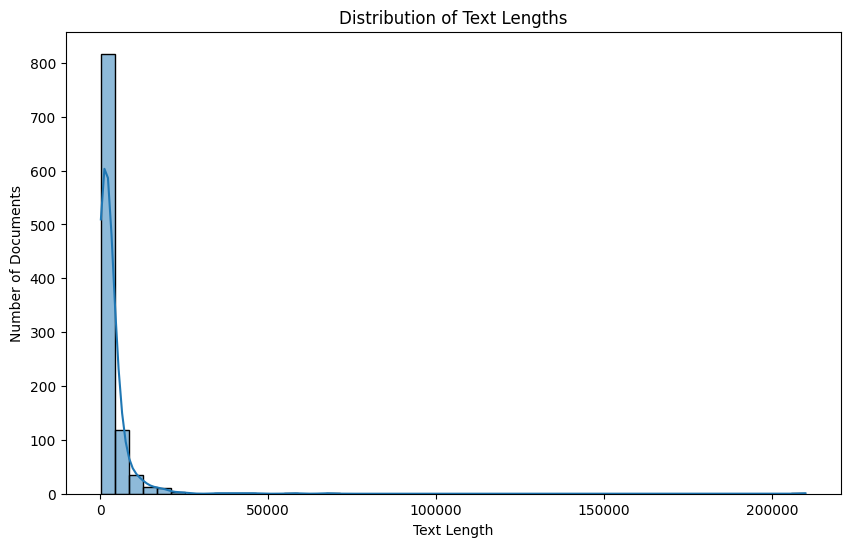


### Top 10 URLs ###
url
None    1000
Name: count, dtype: int64

### Language Distribution (if available) ###
language
None    1000
Name: count, dtype: int64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming data_reader from the previous cell is accessible and has been run.
# If not, you might need to re-run the previous cell or define data_reader here.

documents_data = []
for i, document in enumerate(data_reader()):
    # Extract relevant information from each document
    doc_info = {
        'id': document.id,
        'text': document.text,
        'url': None, # Set to None as 'url' attribute is missing
        'timestamp': None, # Set to None as 'timestamp' attribute is missing
        'language': None, # Set to None as 'attributes' (which would contain language) is also missing
    }
    documents_data.append(doc_info)
    # Limit to a reasonable number for initial EDA if data_reader limit is very high
    # For this example, data_reader was already limited to 1000

# Create a pandas DataFrame
df = pd.DataFrame(documents_data)

print("### DataFrame Head ###")
print(df.head())

print("\n### DataFrame Info ###")
print(df.info())

print("\n### Descriptive Statistics for Numerical Columns ###")
print(df.describe(include='all'))

print("\n### Missing Values ###")
print(df.isnull().sum())

# Add a text length column
df['text_length'] = df['text'].apply(lambda x: len(x) if isinstance(x, str) else 0)

print("\n### Text Length Statistics ###")
print(df['text_length'].describe())

# Visualize text length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Number of Documents')
plt.show()

print("\n### Top 10 URLs ###")
# This will now show counts of None if 'url' was always None
print(df['url'].value_counts(dropna=False).head(10))

print("\n### Language Distribution (if available) ###")
if 'language' in df.columns:
    # This will now show counts of None if 'language' was always None
    print(df['language'].value_counts(dropna=False))
